<a href="https://colab.research.google.com/github/AaronYounger/Quantitative-Finance/blob/main/First_Backtest_Backtrader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter Ticker: schl
Enter Start Date (YYYY-MM-DD): 2020-01-01
Enter End Date (YYYY-MM-DD): 2025-01-01
Enter Interval (e.g., 1d, 1h, 1wk) [default 1d]: 1d
Price           Close       High        Low       Open  Volume
Date                                                          
2020-01-02  33.041752  33.456288  32.825849  33.430377  140400
2020-01-03  32.981308  33.171303  32.532230  32.644500  157900
2020-01-06  32.774036  32.903576  32.471771  32.687673  115000
2020-01-07  32.601318  32.869039  32.506321  32.558138   85000
2020-01-08  32.419968  32.756776  32.385422  32.644505  175900
Starting Portfolio Value: 10000.00
Final Portfolio Value: 9971.91
Sharpe Ratio: OrderedDict({'sharperatio': -9.01814088743873})
Max Drawdown: AutoOrderedDict({'len': 721, 'drawdown': 0.4761549261206189, 'moneydown': 47.70893183071166, 'max': AutoOrderedDict({'len': 721, 'drawdown': 0.4890825956721616, 'moneydown': 49.00423567307553})})


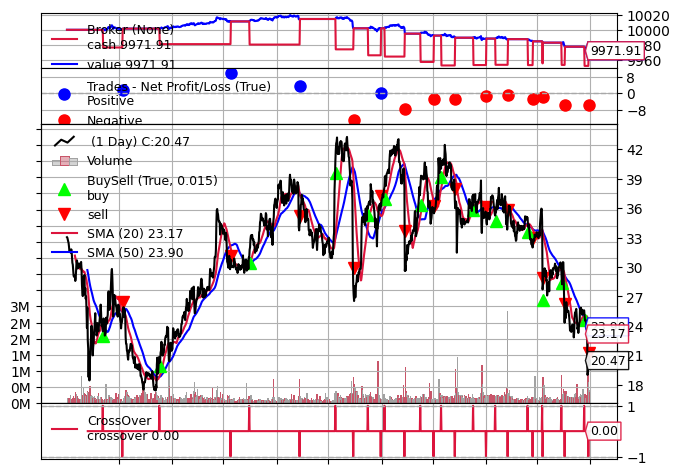

In [12]:
!pip install backtrader
import backtrader as bt
import yfinance as yf
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

# Collect Data from User
class DataCollection:
  def _validate_date(self, s: str) -> str:
    """Validate date format"""
    s = s.strip()
    datetime.strptime(s, "%Y-%m-%d")
    return s

  def get_data(self, ticker: str, start: str, end: str, interval: str = "1d", auto_adjust: bool = True) -> pd.DataFrame:
    """Core Logic, automation with no input()"""
    ticker = ticker.strip().upper()
    start = self._validate_date(start)
    end = self._validate_date(end)

    df = yf.download(
        ticker,
        start=start,
        end=end,
        interval=interval,
        auto_adjust=auto_adjust,
        progress=False,
    )

    if isinstance(df.columns, pd.MultiIndex):
      df.columns = df.columns.get_level_values(0)

    if df.empty:
      raise ValueError(f"No data found for {ticker} between {start} and {end}")

    df.index = pd.to_datetime(df.index)
    return df

  def user_data(self):
    """User-driven input."""
    ticker = input("Enter Ticker: ").strip().upper()
    start = input("Enter Start Date (YYYY-MM-DD): ").strip()
    end = input("Enter End Date (YYYY-MM-DD): ").strip()
    interval = input("Enter Interval (e.g., 1d, 1h, 1wk) [default 1d]: ").strip() or "1d"

    return self.get_data(ticker, start, end, interval=interval)



collector = DataCollection()
data = collector.user_data()
print(data.head())

class SmaCross(bt.Strategy):
  params = (('pfast', 20), ('pslow', 50),)
  def __init__(self):
    sma1 = bt.ind.SMA(period=self.p.pfast)
    sma2 = bt.ind.SMA(period=self.p.pslow)
    self.crossover = bt.ind.CrossOver(sma1, sma2)

  def next(self):
    if not self.position:
      if self.crossover > 0:
        self.buy()
    elif self.crossover < 0:
      self.close()

# Create Backtest
cerebro = bt.Cerebro()
data = bt.feeds.PandasData(dataname=data)
cerebro.adddata(data)

cerebro.addstrategy(SmaCross)

cerebro.broker.setcash(10000.00)

cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')

print(f'Starting Portfolio Value: {cerebro.broker.getvalue():.2f}')
results = cerebro.run()
print(f'Final Portfolio Value: {cerebro.broker.getvalue():.2f}')

strat = results[0]
print(f'Sharpe Ratio: {strat.analyzers.sharpe.get_analysis()}')
print(f'Max Drawdown: {strat.analyzers.drawdown.get_analysis()}')

figs = cerebro.plot(iplot=False)






